# Imputation Benchmark

**Purpose.** Compare Raw, Tangram, gimVI, SpaGE, and REVISE expression profiles using reconstruction metrics and cell-type-conditional Moran statistics for spatial continuity.

**Inputs.** Use `selected_xenium.h5ad` for each part, the combined `results/imputation/adata_sp_impute.h5ad` REVISE reconstruction, and part-specific `Tangram_impute.csv`, `gimVI_impute.csv`, and `SpaGE_impute.csv` files. The preparation section creates `REVISE_impute.h5ad` for each part.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the Sim2Real-ST inputs and complete the Tangram, gimVI, SpaGE, and REVISE imputation workflows for parts 1–3, using the paths declared below. The Raw comparison is read directly from each reference H5AD as an identity control.
2. **Start from released results.** Download the [Sim2Real-ST benchmark and Reproduced benchmark results](https://zenodo.org/records/21921802), then place the extracted files under the raw-data and result directories declared in the configuration section.

Both routes must provide all listed method outputs before metric calculation begins; Raw requires no separate prediction file.

After completing either path, run this notebook from top to bottom.

## 1. Configuration

Define the repository contract, benchmark cases, method names, metric names, and output directories.

In [1]:
# [CONFIG] Imports
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

import sys
sys.path.append("../../")
from revise.analysis.metrics import compute_metric

In [ ]:
# [CONFIG] Paths, cases, methods, metrics, and output folders
source_path = "../.."
task = "imputation"
parts = ["part3", "part1", "part2"]
methods = ["Raw", "Tangram", "gimVI", "SpaGE", "REVISE"]
metrics = ["PCC", "SSIM", "MSE"]
cell_type_col = "Level1"

sim2real_data_path = f"{source_path}/raw_data/Sim2Real-ST/imputation"
result_path = f"{source_path}/results/imputation"
combined_revise_path = f"{result_path}/adata_sp_impute.h5ad"
output_path = f"{source_path}/output/imputation_benchmark"
metric_output_path = f"{output_path}/metric_result"
spatial_output_path = f"{output_path}/plot_imputation"

Path(metric_output_path).mkdir(parents=True, exist_ok=True)
Path(f"{metric_output_path}/mean").mkdir(parents=True, exist_ok=True)
Path(spatial_output_path).mkdir(parents=True, exist_ok=True)

baseline_files = {
    "Tangram": "Tangram_impute.csv",
    "gimVI": "gimVI_impute.csv",
    "SpaGE": "SpaGE_impute.csv",
}

method_colors = {
    "Raw": "#7f7f7f",
    "Tangram": "#ff7f0e",
    "gimVI": "#2ca02c",
    "SpaGE": "#d62728",
    "REVISE": "#1f77b4",
}

## 2. Input preparation and axis alignment

Split the combined REVISE reconstruction with the declared spatial windows, align each subset to reference cell IDs, and save one `REVISE_impute.h5ad` per part. Tangram, gimVI, and SpaGE CSV files are assembled as in-memory AnnData objects with reference observations and spatial coordinates; no baseline H5AD files are written.

In [3]:
# [DEFINE] Input paths, spatial windows, and basic loaders
PART_BOUNDS = {
    "part1": {"x": (42000, 52000), "y": (8000, 13000)},
    "part2": {"x": (52000, 57000), "y": (13000, 23000)},
    "part3": {"x": (60000, 65000), "y": (10000, 20000)},
}


def reference_path(part):
    return f"{sim2real_data_path}/{part}/selected_xenium.h5ad"


def revise_part_path(part):
    return f"{result_path}/{part}/REVISE_impute.h5ad"


def baseline_expression_path(method, part):
    return f"{result_path}/{part}/{baseline_files[method]}"


def _canonicalize_gene_names(adata):
    work = adata.copy()
    gene_names = pd.Index([str(gene).upper() for gene in work.var_names])
    if gene_names.has_duplicates:
        raise ValueError("gene names are duplicated after upper-casing")
    work.var_names = gene_names
    return work


def load_reference(part):
    return _canonicalize_gene_names(sc.read_h5ad(reference_path(part)))


def subset_revise_by_window(combined, part):
    bounds = PART_BOUNDS[part]
    spatial = np.asarray(combined.obsm["spatial"])
    mask = (
        (spatial[:, 0] >= bounds["x"][0])
        & (spatial[:, 0] <= bounds["x"][1])
        & (spatial[:, 1] >= bounds["y"][0])
        & (spatial[:, 1] <= bounds["y"][1])
    )
    return combined[mask].copy()

In [4]:
# [DEFINE] Part preparation, baseline assembly, and axis alignment
def _ordered_overlap(reference_names, candidate_names):
    candidate_set = set(candidate_names)
    return pd.Index([name for name in reference_names if name in candidate_set])


def prepare_revise_parts():
    combined = _canonicalize_gene_names(sc.read_h5ad(combined_revise_path))
    for part in parts:
        reference = load_reference(part)
        prediction = subset_revise_by_window(combined, part)
        cell_names = _ordered_overlap(reference.obs_names, prediction.obs_names)
        if len(cell_names) == 0:
            raise ValueError(f"{part} has no shared cells between the reference and REVISE output")

        prediction = prediction[cell_names].copy()
        reference_aligned = reference[cell_names]
        prediction.obs = reference_aligned.obs.copy()
        prediction.obsm["spatial"] = np.asarray(
            reference_aligned.obsm["spatial"]
        ).copy()

        destination = Path(revise_part_path(part))
        destination.parent.mkdir(parents=True, exist_ok=True)
        prediction.write_h5ad(destination)
        print(f"Saved aligned REVISE input: {destination}")


def load_baseline_expression(method, part):
    expression = pd.read_csv(baseline_expression_path(method, part), index_col=0)
    expression.columns = pd.Index(
        [str(gene).upper() for gene in expression.columns]
    )
    if expression.columns.has_duplicates:
        raise ValueError(
            f"{method} gene names are duplicated after upper-casing for {part}"
        )

    reference = load_reference(part)
    cell_names = _ordered_overlap(reference.obs_names, expression.index)
    if len(cell_names) == 0:
        raise ValueError(f"{method} and the reference have no overlapping cells for {part}")

    reference_aligned = reference[cell_names]
    prediction = ad.AnnData(
        X=expression.loc[cell_names].to_numpy(),
        obs=reference_aligned.obs.copy(),
        var=pd.DataFrame(index=expression.columns.copy()),
    )
    prediction.obsm["spatial"] = np.asarray(
        reference_aligned.obsm["spatial"]
    ).copy()
    return prediction


def load_method_expression(method, part):
    if method == "Raw":
        return load_reference(part)
    if method == "REVISE":
        return _canonicalize_gene_names(sc.read_h5ad(revise_part_path(part)))
    if method in baseline_files:
        return load_baseline_expression(method, part)
    raise ValueError(f"Unknown imputation method: {method}")


def align_expression(reference, prediction):
    reference = _canonicalize_gene_names(reference)
    prediction = _canonicalize_gene_names(prediction)
    cell_names = _ordered_overlap(reference.obs_names, prediction.obs_names)
    gene_names = _ordered_overlap(reference.var_names, prediction.var_names)

    if len(cell_names) == 0:
        raise ValueError("reference and prediction have no overlapping cells")
    if len(gene_names) == 0:
        raise ValueError("reference and prediction have no overlapping genes")

    reference_aligned = reference[cell_names, gene_names].copy()
    prediction_aligned = prediction[cell_names, gene_names].copy()
    if reference_aligned.shape != prediction_aligned.shape:
        raise ValueError("aligned reference and prediction shapes differ")
    return reference_aligned, prediction_aligned


def make_spatial_adata(reference, prediction):
    reference_aligned, prediction_aligned = align_expression(
        reference, prediction
    )
    prediction_aligned.obs = reference_aligned.obs.copy()
    prediction_aligned.obsm["spatial"] = np.asarray(
        reference_aligned.obsm["spatial"]
    ).copy()
    return prediction_aligned

In [5]:
# [PREPARE] Split and align the combined REVISE reconstruction
prepare_revise_parts()

Saved aligned REVISE input: ../../results/imputation/part3/REVISE_impute.h5ad
Saved aligned REVISE input: ../../results/imputation/part1/REVISE_impute.h5ad
Saved aligned REVISE input: ../../results/imputation/part2/REVISE_impute.h5ad


In [6]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
reference = load_reference(parts[1])
reference

AnnData object with n_obs × n_vars = 14060 × 422
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'Level1_colors'
    obsm: 'spatial'

## 3. Expression reconstruction metrics

Align shared cells and genes, compute PCC, SSIM, and MSE, save per-gene and mean tables, and plot the method comparison.

In [7]:
# [DEFINE] Helper functions.
from revise.utils import build_run_logger

logger_name = "Compute_imputation"
log_dir = Path(f"{source_path}/logs/{logger_name}")
logger = build_run_logger(run_name=logger_name,
            run_dir=log_dir
        )
def _metric_table(metrics_df, method, part):
    result = metrics_df.copy()
    if "Gene" not in result.columns:
        result = result.rename_axis("Gene").reset_index()
    result["Gene"] = result["Gene"].astype(str).str.upper()

    missing_metrics = [metric for metric in metrics if metric not in result.columns]
    if missing_metrics:
        raise KeyError(f"missing expression metrics: {missing_metrics}")

    result = result[["Gene", *metrics]].copy()
    result["Method"] = method
    result["Part"] = part
    return result.melt(
        id_vars=["Gene", "Method", "Part"],
        value_vars=metrics,
        var_name="Metric",
        value_name="Value",
    )


def compute_expression_results(part):
    reference = load_reference(part)
    result_frames = []
    for method in methods:
        prediction = load_method_expression(method, part)
        reference_aligned, prediction_aligned = align_expression(
            reference, prediction
        )
        metrics_df = compute_metric(
            reference_aligned,
            prediction_aligned,
            logger = logger,
            adata_process=False,
            gene_list=None,
            normalize=False,
        )
        result_frames.append(_metric_table(metrics_df, method, part))
    return pd.concat(result_frames, ignore_index=True)


In [8]:
# [DEFINE] Helper functions.
def plot_expression_metrics(metrics_df, metric, ax):
    plot_df = metrics_df.loc[metrics_df["Metric"] == metric]
    sns.boxplot(
        data=plot_df,
        x="Method",
        y="Value",
        order=methods,
        hue="Method",
        palette=method_colors,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    if metric == "MSE":
        ax.set_yscale("log")


In [9]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
expression_part1 = compute_expression_results("part1")
expression_part1.head()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
[2026-08-18 14:10:55] [INFO] [metrics.py:127] PCC: 0.2013, 0.7998, -0.0398
[2026-08-18 14:10:55] [INFO] [metrics.py:128] SSIM: 0.3784, 0.9698, 0.0006
[2026-08-18 14:10:55] [INFO] [metrics.py:129] MSE: 8966.3257, 313352.5682, 23.8334
[2026-08-18 14:10:55] [INFO] [metrics.py:130] NRMSE: 7.5184, 148.9996, 0.7741
[2026-08-18 14:10:56] [INFO] [metrics.py:127] PCC: 0.1818, 0.8282, -0.1279
[2026-08-18 14:10:56] [INFO] [metrics.py:128] SSIM: 0.3655, 0.9273, 0.0032
[2026-08-18 14:10:56] [INFO] [metrics.py:129] MSE: 12171.7788, 889181.6499, 32.3826
[2026-08-18 14:10:56] [INFO] [metrics.py:130] NRMSE: 8.3489, 101.3870, 0.7627
[2026-08-18 14:10:57] [INFO] [metrics.py:127] PCC: 0.2038, 0.8505, -0.0202
[2026-08-18 14:10:57] [INFO] [metrics.py:128] SSIM: 0.4566, 0.9706, -0.0007
[2026-08-18 14:10:57] [INFO] [metrics.py:129] MSE: 11103.5396, 670521.8916, 31.9291
[2026-08-18 14:10:57] [INFO] [metrics.py:130]

,Gene,Method,Part,Metric,Value
0,ACP5,Tangram,part1,PCC,0.395681
1,ACTA2,Tangram,part1,PCC,0.651068
2,ADH1C,Tangram,part1,PCC,0.242525
3,ADRA2A,Tangram,part1,PCC,0.056746
4,AFAP1L2,Tangram,part1,PCC,0.083367


In [10]:
# [RUN] Compute and save expression reconstruction metrics
expression_results = pd.concat(
    [compute_expression_results(part) for part in parts],
    ignore_index=True,
)

expression_means = []
for part in parts:
    part_results = expression_results.loc[expression_results["Part"] == part]
    for metric in metrics:
        metric_results = part_results.loc[
            part_results["Metric"] == metric,
            ["Method", "Value", "Part", "Metric", "Gene"],
        ]
        metric_results.to_csv(
            f"{metric_output_path}/{part}_{metric}.csv", index=False
        )

    means = (
        part_results.groupby(["Method", "Metric"], as_index=False)["Value"]
        .mean()
        .pivot(index="Method", columns="Metric", values="Value")
        .reindex(columns=metrics)
        .reset_index()
    )
    means.to_csv(f"{metric_output_path}/mean/{part}.csv", index=False)
    expression_means.append(means.assign(Part=part))

expression_summary = pd.concat(expression_means, ignore_index=True)
expression_summary.to_csv(
    f"{output_path}/expression_mean_summary.csv", index=False
)


[2026-08-18 14:10:58] [INFO] [metrics.py:127] PCC: 0.2086, 0.8611, -0.1122
[2026-08-18 14:10:58] [INFO] [metrics.py:128] SSIM: 0.2471, 0.8364, 0.0365
[2026-08-18 14:10:58] [INFO] [metrics.py:129] MSE: 3634.7623, 91886.5173, 37.9202
[2026-08-18 14:10:58] [INFO] [metrics.py:130] NRMSE: 6.8180, 58.1844, 0.5827
[2026-08-18 14:10:58] [INFO] [metrics.py:127] PCC: 0.2429, 0.8122, -0.0099
[2026-08-18 14:10:58] [INFO] [metrics.py:128] SSIM: 0.3508, 0.8592, 0.0862
[2026-08-18 14:10:58] [INFO] [metrics.py:129] MSE: 2771.8626, 37916.5480, 25.7776
[2026-08-18 14:10:58] [INFO] [metrics.py:130] NRMSE: 6.0969, 36.9485, 0.4444
[2026-08-18 14:10:59] [INFO] [metrics.py:127] PCC: 0.3115, 0.9268, 0.0373
[2026-08-18 14:10:59] [INFO] [metrics.py:128] SSIM: 0.3360, 0.8788, 0.0840
[2026-08-18 14:10:59] [INFO] [metrics.py:129] MSE: 2687.7810, 39262.5898, 35.3976
[2026-08-18 14:10:59] [INFO] [metrics.py:130] NRMSE: 6.1891, 44.7921, 0.4522
[2026-08-18 14:11:00] [INFO] [metrics.py:127] PCC: 0.2682, 0.9506, -0.0257

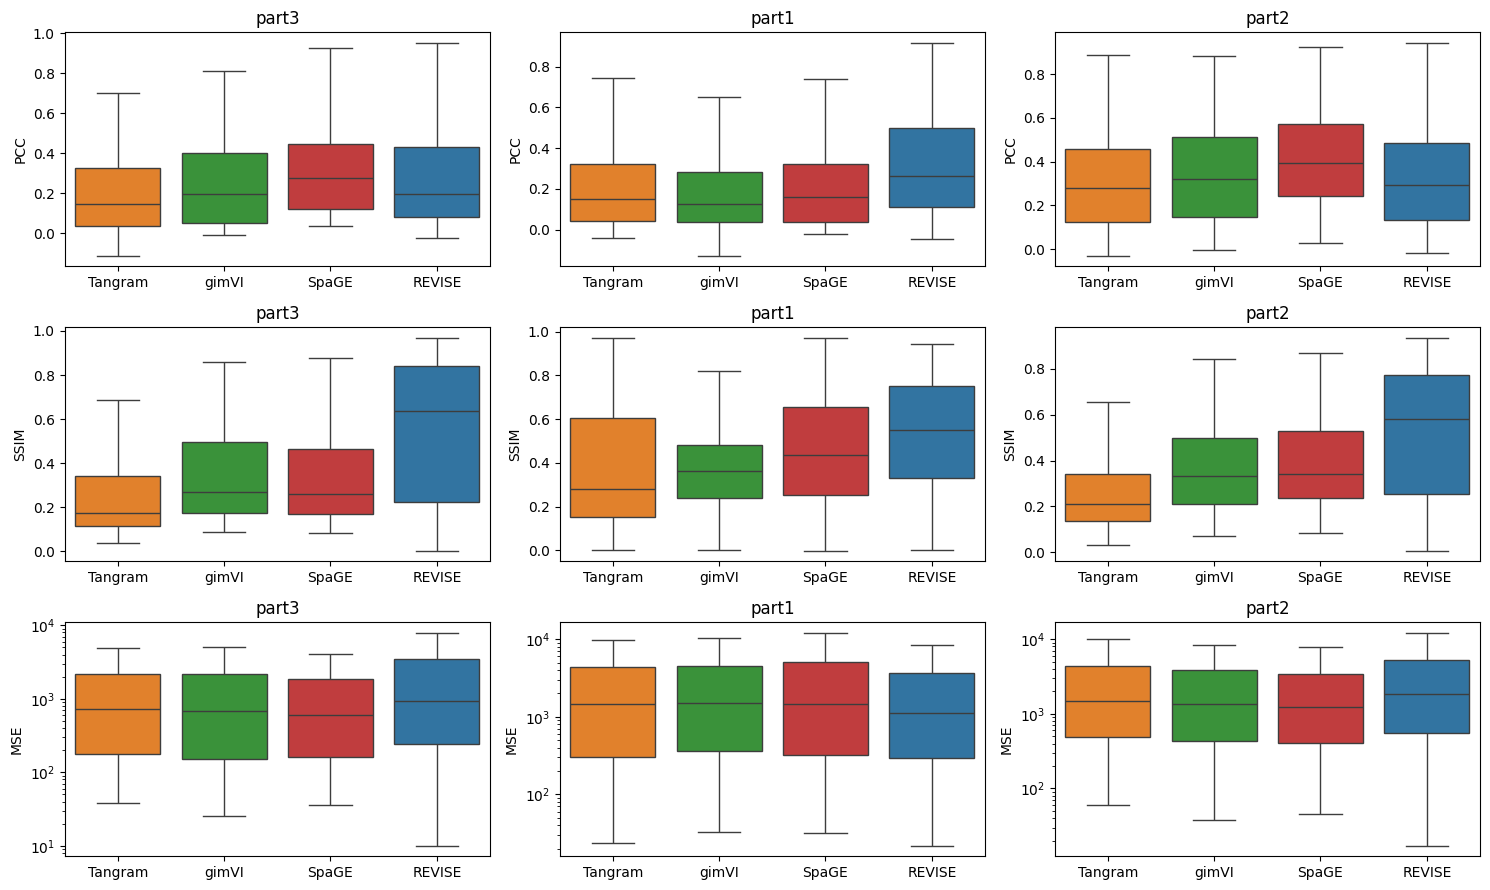

In [11]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
fig, axes = plt.subplots(len(metrics), len(parts), figsize=(15, 9), squeeze=False)
for column, part in enumerate(parts):
    part_results = expression_results.loc[expression_results["Part"] == part]
    for row, metric in enumerate(metrics):
        plot_expression_metrics(part_results, metric, axes[row, column])
        axes[row, column].set_title(part)
fig.tight_layout()
fig.savefig(f"{output_path}/metric.pdf", dpi=300)
plt.show()


## 4. Conditional Moran and spatial continuity

Compute `I_same` and `I_diff` with cell-type-aware spatial connectivity. These columns retain compatibility with the historical MISC/MIDC outputs.

In [12]:
# [DEFINE] Helper functions.
def compute_conditional_moran(adata, cell_type_col=cell_type_col):
    work = adata.copy()
    sc.pp.normalize_total(work, target_sum=1e4)
    sc.pp.log1p(work)

    sq.gr.spatial_neighbors(work)
    connectivity = work.obsp["spatial_connectivities"].tocoo()
    labels = work.obs[cell_type_col].to_numpy()

    same_mask = labels[connectivity.row] == labels[connectivity.col]
    diff_mask = ~same_mask
    same_connectivity = connectivity.copy()
    diff_connectivity = connectivity.copy()
    same_connectivity.data[~same_mask] = 0
    diff_connectivity.data[~diff_mask] = 0
    work.obsp["spatial_connectivities_same"] = same_connectivity.tocsr()
    work.obsp["spatial_connectivities_diff"] = diff_connectivity.tocsr()

    sq.gr.spatial_autocorr(
        work,
        connectivity_key="spatial_connectivities_same",
        mode="moran",
        genes=work.var_names,
        n_perms=1,
        n_jobs=1,
    )
    same = work.uns["moranI"]["I"].loc[work.var_names].rename("I_same")
    same = same.mask((same >= 1) | (same <= -1))

    sq.gr.spatial_autocorr(
        work,
        connectivity_key="spatial_connectivities_diff",
        mode="moran",
        genes=work.var_names,
        n_perms=1,
        n_jobs=1,
    )
    diff = work.uns["moranI"]["I"].loc[work.var_names].rename("I_diff")
    diff = diff.mask((diff >= 1) | (diff <= -1))

    return pd.concat([same, diff], axis=1)


In [13]:
# [DEFINE] Helper functions.
def compute_spatial_results(part, methods):
    reference = load_reference(part)
    result_frames = []
    for method in methods:
        prediction = load_method_expression(method, part)
        spatial_adata = make_spatial_adata(reference, prediction)
        moran = compute_conditional_moran(spatial_adata, cell_type_col)
        moran.to_csv(f"{spatial_output_path}/{method}_{part}.csv")
        result_frames.append(
            moran.reset_index()
            .rename(columns={"index": "Gene"})
            .assign(Method=method, Part=part)
        )
    return pd.concat(result_frames, ignore_index=True)


In [14]:
# [DEFINE] Helper functions.
def plot_conditional_moran(summary_df, part, ax):
    part_summary = summary_df.loc[summary_df["Part"] == part].set_index("Method")
    positions = np.arange(len(methods))
    width = 0.8

    for position, method in enumerate(methods):
        row = part_summary.loc[method]
        ax.bar(
            positions[position],
            row["I_same_mean"],
            width,
            color=method_colors[method],
            yerr=2 * row["I_same_sem"],
            capsize=5,
        )
        ax.bar(
            positions[position],
            -row["I_diff_mean"],
            width,
            color=method_colors[method],
            yerr=2 * row["I_diff_sem"],
            capsize=5,
            alpha=0.5,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(positions, methods, rotation=45, ha="right")
    ax.set_ylim(-0.5, 1)
    ax.set_title(part)
    ax.set_ylabel("I_same / -I_diff")
    ax.grid(axis="y", linestyle="--", alpha=0.3)


In [15]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
spatial_reference = load_reference("part1")
gimvi_prediction = load_method_expression("gimVI", "part1")
gimvi_spatial = make_spatial_adata(spatial_reference, gimvi_prediction)
gimvi_spatial


AnnData object with n_obs × n_vars = 13952 × 364
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1'
    obsm: 'spatial'

In [16]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
revise_prediction = load_method_expression("REVISE", "part1")
revise_spatial = make_spatial_adata(spatial_reference, revise_prediction)
revise_spatial


AnnData object with n_obs × n_vars = 13325 × 343
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'Level1', 'X_pca', 'cluster_subtype', 'spatial'

In [17]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
conditional_moranI = compute_conditional_moran(gimvi_spatial, cell_type_col=cell_type_col)
conditional_moranI


  0%|          | 0/1 [00:00<?, ?/s]

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/1 [00:00<?, ?/s]

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


,I_same,I_diff
ACP5,0.644253,0.567834
ACTA2,0.756498,-0.069697
ADH1C,0.752730,0.488162
ADRA2A,0.483839,-0.047923
AFAP1L2,0.700537,0.319395
...,...,...
UGT2B17,0.530116,0.152279
VCAN,0.920244,0.090816
VWF,0.586260,0.103188
WFDC2,0.761157,0.342497


In [18]:
# [RUN] Compute and save conditional Moran results
methods = ["Raw", "Tangram", "gimVI", "SpaGE", "REVISE"]
spatial_results = pd.concat(
    [compute_spatial_results(part, methods) for part in parts],
    ignore_index=True,
)

spatial_summary = (
    spatial_results.groupby(["Part", "Method"], as_index=False)
    .agg(
        I_same_mean=("I_same", "mean"),
        I_same_sem=("I_same", "sem"),
        I_diff_mean=("I_diff", "mean"),
        I_diff_sem=("I_diff", "sem"),
    )
    .reindex(
        columns=[
            "Part",
            "Method",
            "I_same_mean",
            "I_same_sem",
            "I_diff_mean",
            "I_diff_sem",
        ]
    )
)
spatial_summary.to_csv(
    f"{output_path}/conditional_moran_summary.csv", index=False
)


  0%|          | 0/1 [00:00<?, ?/s]

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/1 [00:00<?, ?/s]

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/1 [00:00<?, ?/s]

...

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/1 [00:00<?, ?/s]

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/1 [00:00<?, ?/s]

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [19]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
spatial_summary.groupby("Method")[["I_same_mean", "I_diff_mean"]].mean()


,I_same_mean,I_diff_mean
Method,,
REVISE,0.717117,0.099161
Raw,0.136245,0.076987
SpaGE,0.340525,0.152802
Tangram,0.573756,0.275470
gimVI,0.598553,0.319902


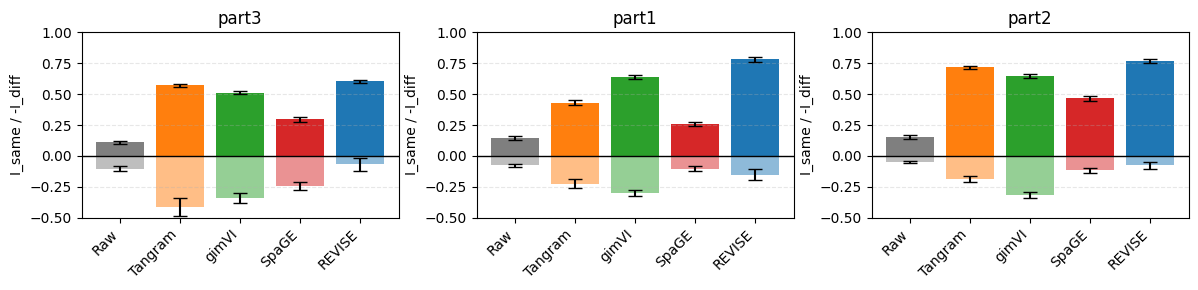

In [ ]:
# [OUTPUT] The displayed output is a preserved historical snapshot; rerun this cell to refresh it.
fig, axes = plt.subplots(1, len(parts), figsize=(12, 3), squeeze=False)
for index, part in enumerate(parts):
    plot_conditional_moran(spatial_summary, part, axes[0, index])
fig.tight_layout()
fig.savefig(f"{output_path}/conditional_moran.pdf", dpi=300)
plt.show()


## 5. Outputs and rerun notes

Part-specific REVISE inputs are written under `results/imputation/<part>/`. Expression and conditional Moran results are written under `output/imputation_benchmark/`. The displayed outputs are retained historical snapshots and may predate the active five-method configuration; they do not validate the current source. Running the notebook from top to bottom refreshes matching derived files but does not remove stale outputs for methods or parts no longer selected.

In [ ]:
# [OUTPUT] Paths for the prepared inputs and derived benchmark results
output_manifest = {
    "prepared_revise": {
        part: revise_part_path(part) for part in parts
    },
    "expression": metric_output_path,
    "spatial": spatial_output_path,
    "expression_summary": f"{output_path}/expression_mean_summary.csv",
    "spatial_summary": f"{output_path}/conditional_moran_summary.csv",
}